In [1]:
from sklearn.metrics import roc_auc_score


def gini(y_true, y_score):
    return 2 * roc_auc_score(y_true, y_score) - 1.0

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import kagglehub
import numpy as np
import os

In [3]:
kaggle_dir = '/root/.kaggle'
os.makedirs(kaggle_dir, exist_ok=True)

!cp kaggle.json {kaggle_dir}/
!chmod 600 {kaggle_dir}/kaggle.json


cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [4]:
kagglehub.competition_download('dota-2-hse-ml-1-course-competition-2026')

'/kaggle/input/competitions/dota-2-hse-ml-1-course-competition-2026'

In [5]:
path_files = kagglehub.competition_download('dota-2-hse-ml-1-course-competition-2026')
train = pd.read_csv(path_files + '/matches_df_train.csv')
test = pd.read_csv(path_files + '/matches_df_test.csv')

In [6]:
print(f'The size of train dataframe in megabytes: \n{train.memory_usage()/2**20}',
      f'The size: {train.memory_usage().sum()/2**20} mb', sep='\n')
print(f'The size of test dataframe in megabytes:\n{test.memory_usage()/2**20}',
      f'The size: {test.memory_usage().sum()/2**20} mb', sep='\n')

The size of train dataframe in megabytes: 
Index          0.000126
match_id       4.891129
date           4.891129
region         4.891129
game_mode      4.891129
duration       4.891129
radiant_win    0.611391
avg_mmr        4.891129
dtype: float64
The size: 29.958288192749023 mb
The size of test dataframe in megabytes:
Index        0.000126
match_id     0.455841
date         0.455841
region       0.455841
game_mode    0.455841
avg_mmr      0.455841
dtype: float64
The size: 2.2793312072753906 mb


In [7]:
print(f'Shape of train dataframe: {train.shape}')
print(f'Shape of test dataframe: {test.shape}')

Shape of train dataframe: (641090, 7)
Shape of test dataframe: (59748, 5)


In [8]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 641090 entries, 0 to 641089
Data columns (total 7 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   match_id     641090 non-null  int64  
 1   date         641090 non-null  object 
 2   region       641090 non-null  object 
 3   game_mode    641090 non-null  int64  
 4   duration     641090 non-null  int64  
 5   radiant_win  641090 non-null  bool   
 6   avg_mmr      472334 non-null  float64
dtypes: bool(1), float64(1), int64(3), object(2)
memory usage: 30.0+ MB


In [9]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59748 entries, 0 to 59747
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   match_id   59748 non-null  int64  
 1   date       59748 non-null  object 
 2   region     59748 non-null  object 
 3   game_mode  59748 non-null  int64  
 4   avg_mmr    44504 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 2.3+ MB


Let`s see the distribution of target column

/tmp/ipykernel_55/3775437630.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=train, x='radiant_win', palette='rocket')


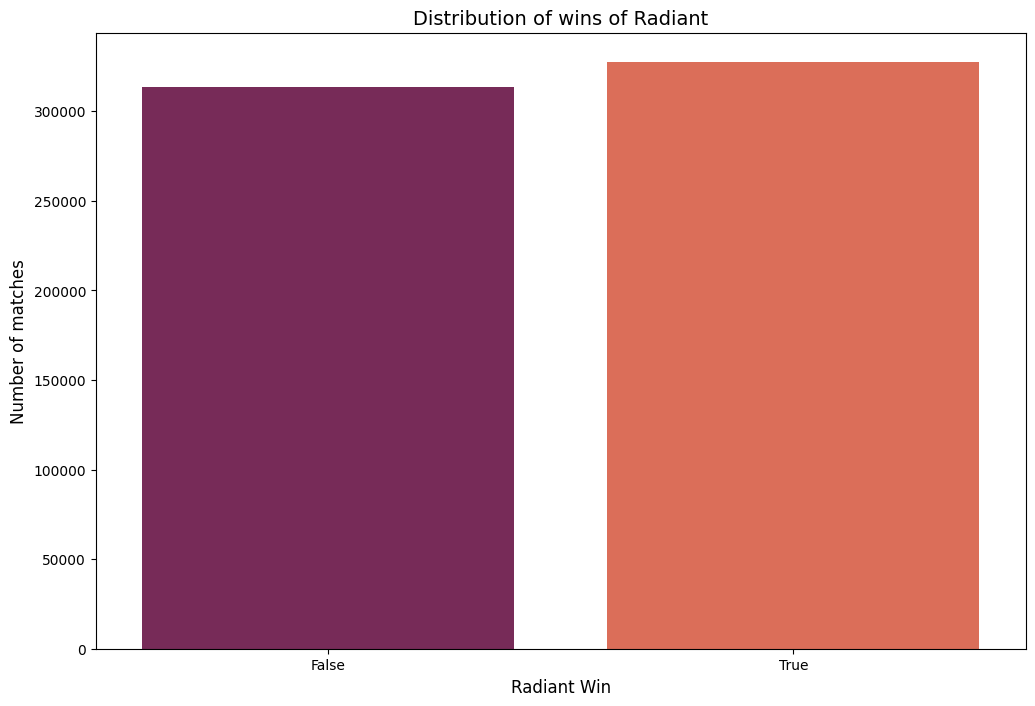

In [10]:
plt.figure(figsize=(12, 8))
sns.countplot(data=train, x='radiant_win', palette='rocket')
plt.title('Distribution of wins of Radiant', fontsize=14)
plt.ylabel('Number of matches', fontsize=12)
plt.xlabel('Radiant Win', fontsize=12)
plt.show()

#### **Region features**
Let`s dive into data about regions. We will generate these plots
1) Regions distribution among train and test
2) Mean value of target grouped by regions

/tmp/ipykernel_55/4198516573.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=train, x='region', palette='rocket', ax=axes[0])
/tmp/ipykernel_55/4198516573.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=test, x='region', palette='rocket', ax=axes[1])


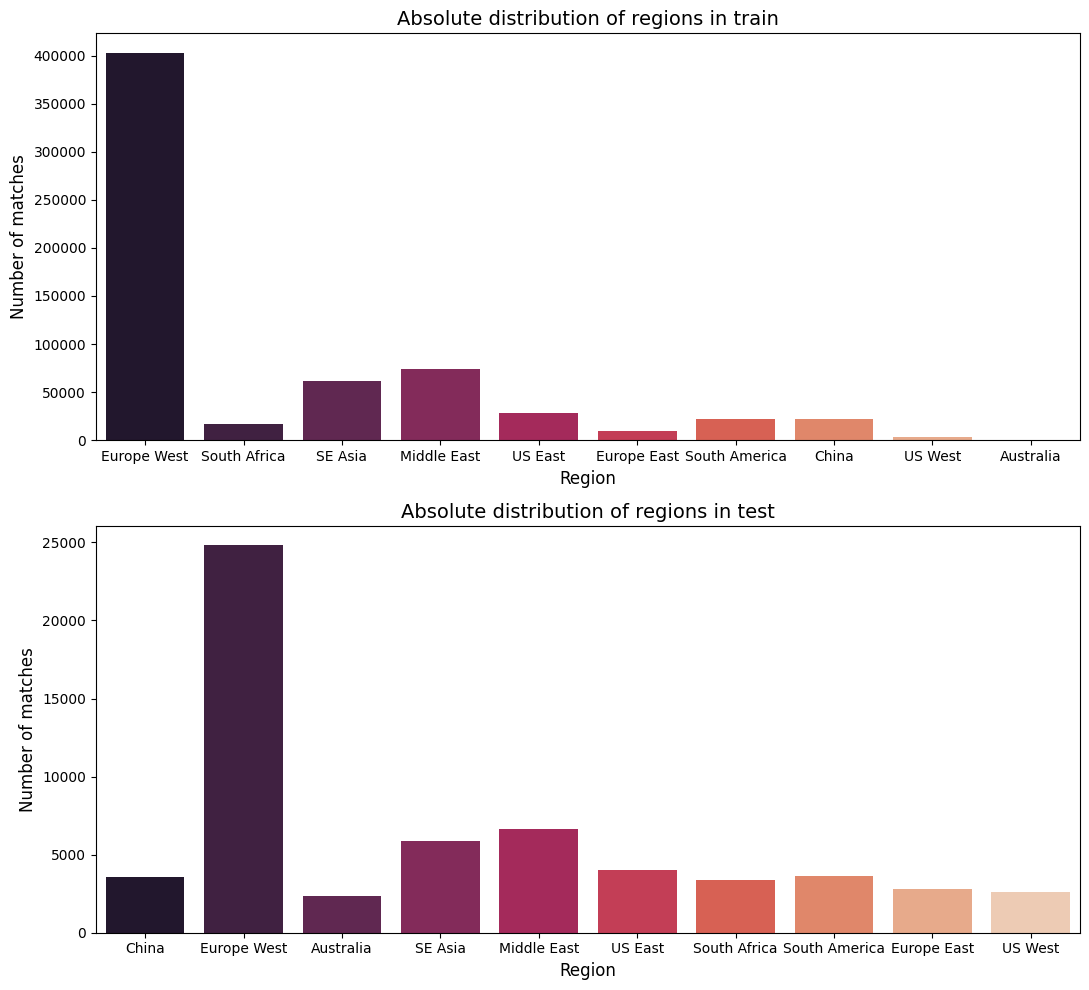

In [11]:
fig, axes = plt.subplots(2, 1, figsize=(11, 10))

sns.countplot(data=train, x='region', palette='rocket', ax=axes[0])
axes[0].set_title('Absolute distribution of regions in train', fontsize=14)
axes[0].set_ylabel('Number of matches', fontsize=12)
axes[0].set_xlabel('Region', fontsize=12)

sns.countplot(data=test, x='region', palette='rocket', ax=axes[1])
axes[1].set_title('Absolute distribution of regions in test', fontsize=14)
axes[1].set_ylabel('Number of matches', fontsize=12)
axes[1].set_xlabel('Region', fontsize=12)

plt.tight_layout()

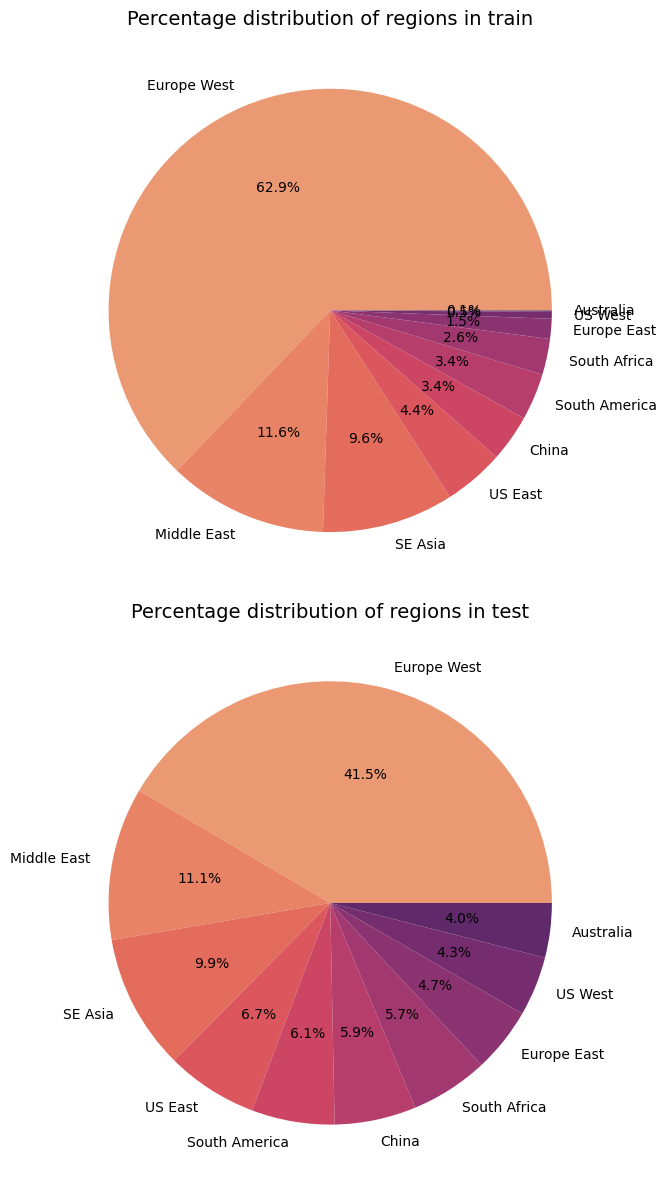

In [12]:
fig, axes = plt.subplots(2, 1, figsize=(11, 12))

train_palette = sns.color_palette("flare", len(train['region'].value_counts()))
axes[0].pie(train['region'].value_counts(), labels=train['region'].value_counts().index,
            colors=train_palette, autopct='%1.1f%%')
axes[0].set_title('Percentage distribution of regions in train', fontsize=14)

test_palette = sns.color_palette("flare", len(test['region'].value_counts()))
axes[1].pie(test['region'].value_counts(), labels=test['region'].value_counts().index, colors=test_palette, autopct='%1.1f%%')
axes[1].set_title('Percentage distribution of regions in test', fontsize=14)


plt.tight_layout()

In [13]:
print('Mean value of target grouped by region')
train[['region', 'radiant_win']].groupby('region').mean()

Mean value of target grouped by region


,radiant_win
region,
Australia,0.533546
China,0.510876
Europe East,0.577204
Europe West,0.534574
Middle East,0.436854
SE Asia,0.501893
South Africa,0.490883
South America,0.483214
US East,0.413281


Encode region feature with One-Hot Encoding

In [14]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(sparse_output=False)
encoded_region_train = ohe.fit_transform(train[['region']])
encoded_region_test = ohe.transform(test[['region']])
encoded_region_train = pd.DataFrame(encoded_region_train, columns=ohe.get_feature_names_out())
encoded_region_test = pd.DataFrame(encoded_region_test, columns=ohe.get_feature_names_out())

train = pd.concat([train, encoded_region_train], axis=1).drop('region',axis=1)
test = pd.concat([test, encoded_region_test], axis=1).drop('region',axis=1)
train.head()

,match_id,date,game_mode,duration,radiant_win,avg_mmr,region_Australia,region_China,region_Europe East,region_Europe West,region_Middle East,region_SE Asia,region_South Africa,region_South America,region_US East,region_US West
0,1,2024-02-12,4,2625,False,3519.7,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2,2024-04-08,2,7526,True,2330.9,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,3,2024-06-16,1,2831,True,1579.6,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,4,2024-09-16,22,1438,False,NaN,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,5,2024-03-31,22,2051,True,NaN,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


#### **Date features** 

In [15]:
train['date'].head()

0    2024-02-12
1    2024-04-08
2    2024-06-16
3    2024-09-16
4    2024-03-31
Name: date, dtype: object

In [16]:
train['date'] = pd.to_datetime(train['date'])
test['date'] = pd.to_datetime(test['date'])

grouped_date = train[['date', 'radiant_win']].groupby('date').mean()

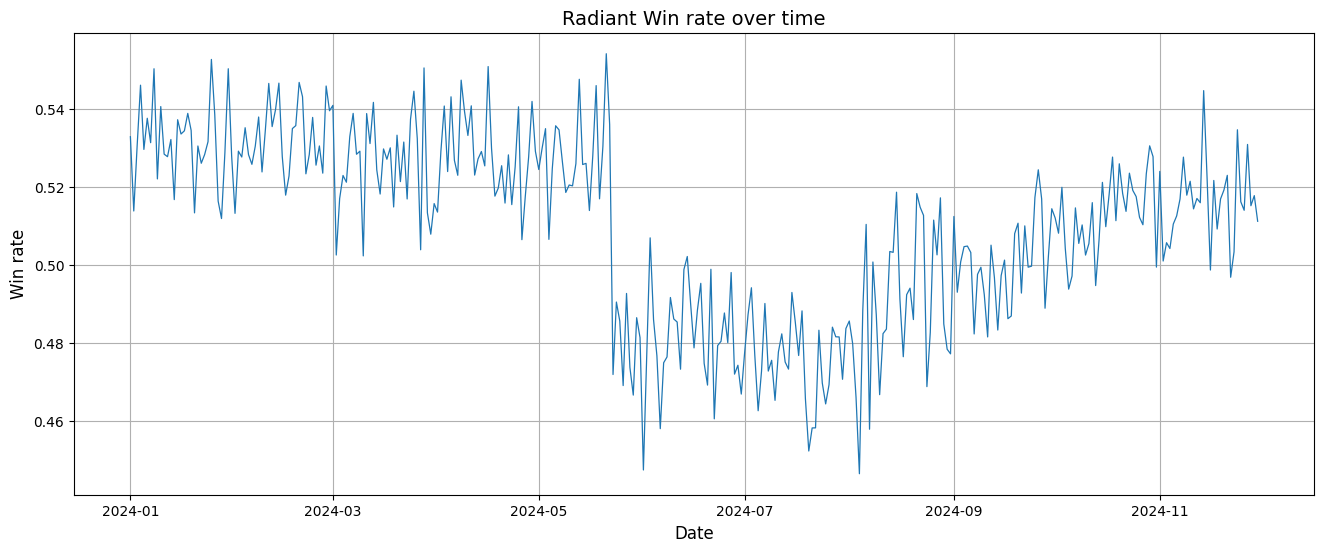

In [17]:
plt.figure(figsize=(16,6))
plt.plot(grouped_date, linewidth=0.9)
plt.title('Radiant Win rate over time', fontsize=14)
plt.ylabel('Win rate', fontsize=12)
plt.xlabel('Date', fontsize=12)
plt.grid(True)
plt.show()

Make new features

In [18]:
train['day'] = train['date'].dt.day
test['day'] = test['date'].dt.day

train['day_week'] = train['date'].dt.dayofweek
test['day_week'] = test['date'].dt.dayofweek

Explanation
1) On weekends, people typically have more free time, allowing them to play more—especially schoolchildren (who may prefer to showcase their skills while playing for a specific side). Let's add a "weekend" flag to our feature set.
2) During the summer, schoolchildren are on vacation, meaning their activity levels peak during this period; adding a feature specifically for the summer season will help us identify schoolchildren more accurately. We can further refine this feature by representing it not merely as a "summer" flag, but as a specific season category; this approach makes it easy to encode while providing a richer amount of information.

In [19]:
train['is_weekend'] = train['date'].dt.weekday >= 5
test['is_weekend'] = test['date'].dt.weekday >= 5
seasons = {'spring': [3,4,5], 'summer': [6,7,8], 'fall':[9,10,11], 'winter':[12,1,2]}
reversed_seasons = {l: k  for k, v in seasons.items() for l in v}
train['season'] = train['date'].dt.month.map(reversed_seasons)
test['season'] = test['date'].dt.month.map(reversed_seasons)
train.head()

,match_id,date,game_mode,duration,radiant_win,avg_mmr,region_Australia,region_China,region_Europe East,region_Europe West,region_Middle East,region_SE Asia,region_South Africa,region_South America,region_US East,region_US West,day,day_week,is_weekend,season
0,1,2024-02-12,4,2625,False,3519.7,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,12,0,False,winter
1,2,2024-04-08,2,7526,True,2330.9,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,8,0,False,spring
2,3,2024-06-16,1,2831,True,1579.6,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,16,6,True,summer
3,4,2024-09-16,22,1438,False,NaN,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,16,0,False,fall
4,5,2024-03-31,22,2051,True,NaN,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,31,6,True,spring


In [20]:
ohe = OneHotEncoder(sparse_output=False)
data_categories_encoded_train = ohe.fit_transform(train[['season', 'day', 'day_week']])
data_categories_encoded_test = ohe.transform(test[['season', 'day', 'day_week']])
encoded_data_categories_train = pd.DataFrame(data_categories_encoded_train, columns=ohe.get_feature_names_out())
encoded_data_categories_test = pd.DataFrame(data_categories_encoded_test, columns=ohe.get_feature_names_out())
train = pd.concat([train, encoded_data_categories_train], axis=1).drop(['day', 'day_week','season'],axis=1)
test = pd.concat([test,encoded_data_categories_test],axis=1).drop(['day', 'day_week','season'],axis=1)
train.head()

,match_id,date,game_mode,duration,radiant_win,avg_mmr,region_Australia,region_China,region_Europe East,region_Europe West,...,day_29,day_30,day_31,day_week_0,day_week_1,day_week_2,day_week_3,day_week_4,day_week_5,day_week_6
0,1,2024-02-12,4,2625,False,3519.7,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2,2024-04-08,2,7526,True,2330.9,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3,2024-06-16,1,2831,True,1579.6,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,4,2024-09-16,22,1438,False,NaN,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5,2024-03-31,22,2051,True,NaN,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [21]:
train = train.drop('date', axis=1)
test = test.drop('date', axis=1)

#### **Training base model**

In [22]:
from sklearn.model_selection import TimeSeriesSplit

cv = TimeSeriesSplit(n_splits = 5)

In [23]:
from sklearn.linear_model import LogisticRegression

dates_features = [col for col in train if col.startswith('day') or col.startswith('season')] +  ['is_weekend']
region_features = [col for col in train if col.startswith('region')]
combined_features = dates_features + region_features

history_gini = {'date features':[], 'region features':[], 'combined features': []}

for features_name, feature_list in zip(history_gini.keys(), [dates_features, region_features, combined_features]):
  for fold, (train_index, val_index) in enumerate(cv.split(train[feature_list])):
    X_train, X_val = train[feature_list].iloc[train_index], train[feature_list].iloc[val_index]
    y_train, y_val = train['radiant_win'].iloc[train_index], train['radiant_win'].iloc[val_index]
    model = LogisticRegression()
    model.fit(X_train, y_train)
    predict_probs = model.predict_proba(X_val)[:, 1]
    score = gini(y_val, predict_probs)
    history_gini[features_name].append(score)



In [24]:
for features_name, scores in history_gini.items():
  print(features_name)
  for fold, score in enumerate(scores):
    print(f"Fold {fold+1}: {score.item()}")
  print(f"Average Gini: {np.mean(scores)}")
  print('--------------------------')

date features
Fold 1: 0.03233837479743107
Fold 2: 0.036342427014518064
Fold 3: 0.04318614605056337
Fold 4: 0.03715167009833098
Fold 5: 0.04508554621122274
Average Gini: 0.038820832834413246
--------------------------
region features
Fold 1: 0.07479096288009135
Fold 2: 0.0764743530982428
Fold 3: 0.07952511495741788
Fold 4: 0.07355349000407863
Fold 5: 0.07551280006830763
Average Gini: 0.07597134420162766
--------------------------
combined features
Fold 1: 0.08847701186605983
Fold 2: 0.09232089188406922
Fold 3: 0.09839727136569443
Fold 4: 0.09076285645205551
Fold 5: 0.09664882097322769
Average Gini: 0.09332137050822134
--------------------------


#### **Numeric features** 

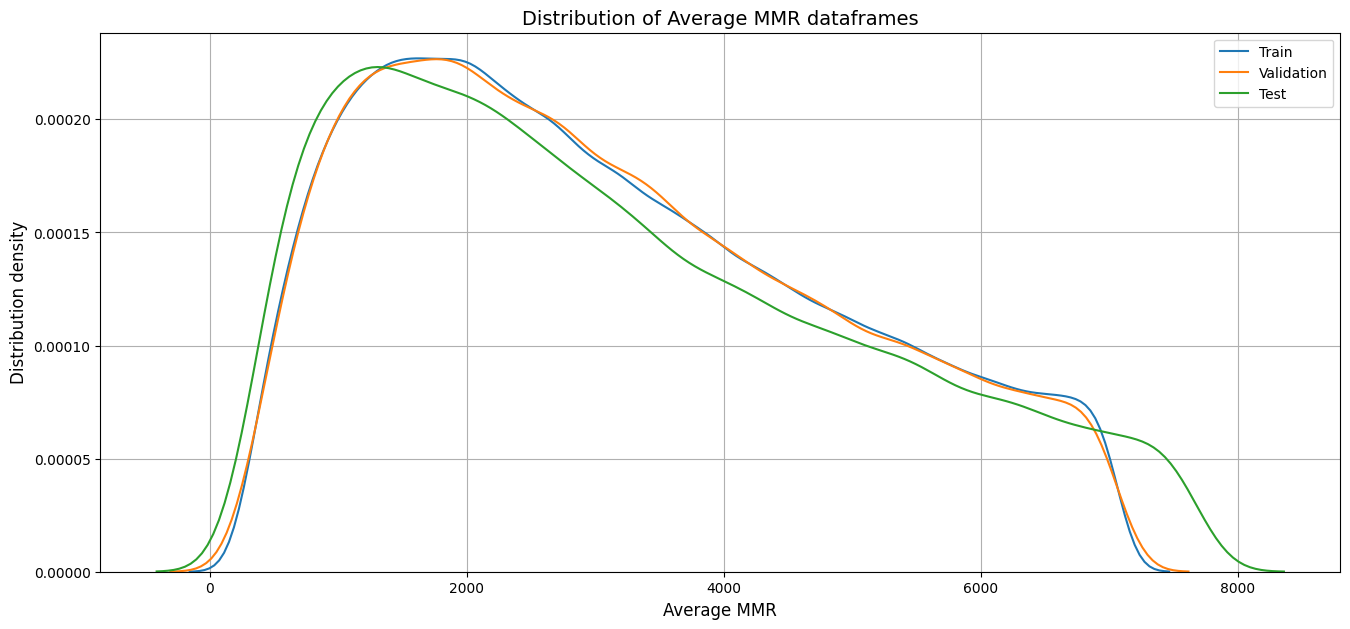

In [25]:
plt.figure(figsize=(16,7))
sns.kdeplot(train['avg_mmr'].iloc[train_index], label='Train')
sns.kdeplot(train['avg_mmr'].iloc[val_index], label='Validation')
sns.kdeplot(test['avg_mmr'], label='Test')
plt.legend()
plt.title('Distribution of Average MMR dataframes', fontsize=14)
plt.xlabel('Average MMR', fontsize=12)
plt.ylabel('Distribution density',fontsize=12)
plt.grid(True)
plt.show()

Transform target columns in order to stabilize data

In [26]:
log_mmr = np.log(1+train['avg_mmr'])
sqrt_mmr = np.sqrt(train['avg_mmr'])
inv_mmr = 1/(1+train['avg_mmr'])
explog_mmr = np.exp(np.log(train['avg_mmr']))

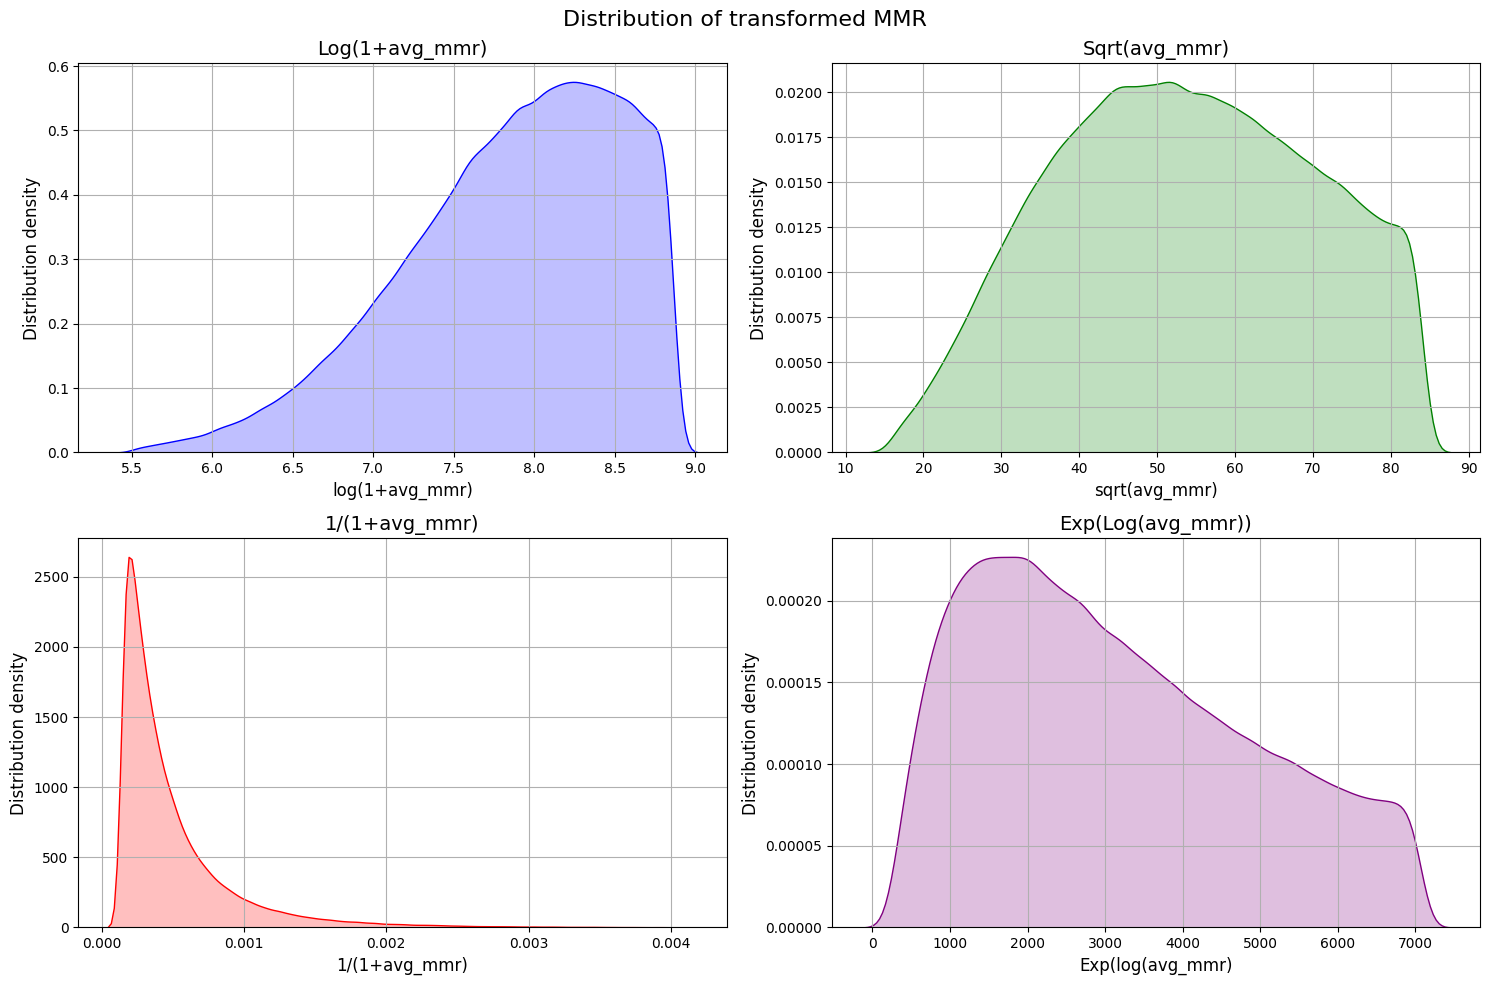

In [27]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Distribution of transformed MMR', fontsize=16)

sns.kdeplot(log_mmr, ax=axes[0, 0], color='blue', fill=True)
axes[0, 0].set_title('Log(1+avg_mmr)', fontsize=14)
axes[0, 0].set_xlabel('log(1+avg_mmr)', fontsize=12)
axes[0, 0].set_ylabel('Distribution density', fontsize=12)

sns.kdeplot(sqrt_mmr, ax=axes[0,1], color='green', fill=True)
axes[0, 1].set_title('Sqrt(avg_mmr)', fontsize=14)
axes[0, 1].set_xlabel('sqrt(avg_mmr)', fontsize=12)
axes[0, 1].set_ylabel('Distribution density', fontsize=12)

sns.kdeplot(inv_mmr, ax=axes[1,0], color='red',fill=True)
axes[1, 0].set_title('1/(1+avg_mmr)', fontsize=14)
axes[1, 0].set_xlabel('1/(1+avg_mmr)', fontsize=12)
axes[1, 0].set_ylabel('Distribution density', fontsize=12)

sns.kdeplot(explog_mmr, ax=axes[1,1], color='purple',fill=True)
axes[1, 1].set_title('Exp(Log(avg_mmr))', fontsize=14)
axes[1, 1].set_xlabel('Exp(log(avg_mmr)',fontsize=12)
axes[1, 1].set_ylabel('Distribution density', fontsize=12)

for ax in axes.flat:
    ax.grid(True)

plt.grid(True)
plt.tight_layout()
plt.show()

I choose the sqrt(avg_mmr) transformation because it makes the distribution more symmetrical, eliminates the right tail, keeps the values ​​within a range that is neither too small nor too large for the model, and is easily interpretable.

In [28]:
print("Rate of missed matches at the average MMR:", round(train['avg_mmr'].isna().sum().item()/len(train) * 100,2), '%')

Rate of missed matches at the average MMR: 26.32 %


In [29]:
train['mmr_missing'] = train['avg_mmr'].isna()
train['avg_mmr'] = train['avg_mmr'].fillna(train['avg_mmr'].median()) # тут есть небольшой leakage на валидации
test['mmr_missing'] = test['avg_mmr'].isna()
test['avg_mmr'] = test['avg_mmr'].fillna(train['avg_mmr'].median()) #все равно распределение очень похоже
train.head()

,match_id,game_mode,duration,radiant_win,avg_mmr,region_Australia,region_China,region_Europe East,region_Europe West,region_Middle East,...,day_30,day_31,day_week_0,day_week_1,day_week_2,day_week_3,day_week_4,day_week_5,day_week_6,mmr_missing
0,1,4,2625,False,3519.70,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,False
1,2,2,7526,True,2330.90,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,False
2,3,1,2831,True,1579.60,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,False
3,4,22,1438,False,2846.85,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,True
4,5,22,2051,True,2846.85,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,True


In [30]:
train['avg_mmr_sqrt'] = np.sqrt(train['avg_mmr'])
test['avg_mmr_sqrt'] = np.sqrt(test['avg_mmr'])

In [31]:
defaultmmr_features = combined_features + ['avg_mmr']
sqrtmmr_features = combined_features + ['avg_mmr_sqrt']

history_gini['mmr features'] = []
history_gini['mmr_sqrt features'] = []
feature_sets = {'mmr features': defaultmmr_features, 'mmr_sqrt features': sqrtmmr_features}

for features_name, feature_list in feature_sets.items():
    for fold, (train_index, val_index) in enumerate(cv.split(train)):
        X_train,X_val = train[feature_list].iloc[train_index], train[feature_list].iloc[val_index]
        y_train,y_val = train['radiant_win'].iloc[train_index], train['radiant_win'].iloc[val_index]
        model = LogisticRegression(max_iter = 3000)
        model.fit(X_train, y_train)
        predict_probs = model.predict_proba(X_val)[:, 1]
        score = gini(y_val, predict_probs)
        history_gini[features_name].append(score)

In [32]:
for features_name, scores in history_gini.items():
  print(features_name)
  for fold, score in enumerate(scores):
    print(f"Fold {fold+1}: {score.item()}")
  print(f"Average Gini: {np.mean(scores)}")
  print('--------------------------')

date features
Fold 1: 0.03233837479743107
Fold 2: 0.036342427014518064
Fold 3: 0.04318614605056337
Fold 4: 0.03715167009833098
Fold 5: 0.04508554621122274
Average Gini: 0.038820832834413246
--------------------------
region features
Fold 1: 0.07479096288009135
Fold 2: 0.0764743530982428
Fold 3: 0.07952511495741788
Fold 4: 0.07355349000407863
Fold 5: 0.07551280006830763
Average Gini: 0.07597134420162766
--------------------------
combined features
Fold 1: 0.08847701186605983
Fold 2: 0.09232089188406922
Fold 3: 0.09839727136569443
Fold 4: 0.09076285645205551
Fold 5: 0.09664882097322769
Average Gini: 0.09332137050822134
--------------------------
mmr features
Fold 1: 0.11314245672255185
Fold 2: 0.11419013104262876
Fold 3: 0.12200460137565705
Fold 4: 0.11590444370194675
Fold 5: 0.11944063301798002
Average Gini: 0.11693645317215288
--------------------------
mmr_sqrt features
Fold 1: 0.11798210482488947
Fold 2: 0.11881647417058572
Fold 3: 0.12669764191289046
Fold 4: 0.12104916635136442
Fold

We clearly need to keep only `sqrt`, as it improves the result and outperforms the standard `avg_mmr`

In [33]:
all_features = sqrtmmr_features + ['mmr_missing']
history_gini['mmr_missing features'] = []
for fold, (train_index, val_index) in enumerate(cv.split(train)):
    X_train,X_val = train[all_features].iloc[train_index], train[all_features].iloc[val_index]
    y_train,y_val = train['radiant_win'].iloc[train_index], train['radiant_win'].iloc[val_index]
    model = LogisticRegression(max_iter = 3000)
    model.fit(X_train, y_train)
    predict_probs = model.predict_proba(X_val)[:, 1]
    score = gini(y_val, predict_probs)
    history_gini['mmr_missing features'].append(score)

In [34]:
for features_name, scores in history_gini.items():
  print(features_name)
  for fold, score in enumerate(scores):
    print(f"Fold {fold+1}: {score.item()}")
  print(f"Average Gini: {np.mean(scores)}")
  print('--------------------------')

date features
Fold 1: 0.03233837479743107
Fold 2: 0.036342427014518064
Fold 3: 0.04318614605056337
Fold 4: 0.03715167009833098
Fold 5: 0.04508554621122274
Average Gini: 0.038820832834413246
--------------------------
region features
Fold 1: 0.07479096288009135
Fold 2: 0.0764743530982428
Fold 3: 0.07952511495741788
Fold 4: 0.07355349000407863
Fold 5: 0.07551280006830763
Average Gini: 0.07597134420162766
--------------------------
combined features
Fold 1: 0.08847701186605983
Fold 2: 0.09232089188406922
Fold 3: 0.09839727136569443
Fold 4: 0.09076285645205551
Fold 5: 0.09664882097322769
Average Gini: 0.09332137050822134
--------------------------
mmr features
Fold 1: 0.11314245672255185
Fold 2: 0.11419013104262876
Fold 3: 0.12200460137565705
Fold 4: 0.11590444370194675
Fold 5: 0.11944063301798002
Average Gini: 0.11693645317215288
--------------------------
mmr_sqrt features
Fold 1: 0.11798210482488947
Fold 2: 0.11881647417058572
Fold 3: 0.12669764191289046
Fold 4: 0.12104916635136442
Fold

`mmr_missing` proved to be a very useful feature, noticeably improving the results; let's keep it.

#### **Players data** 

In [35]:
players = pd.read_csv(path_files + '/player_df.csv')
heroes = pd.read_csv(path_files + '/Constants.Heroes.csv')

In [36]:
players.head()

,player_slot,account_id,hero_id,kills,deaths,assists,gold,last_hits,denies,gold_per_min,xp_per_min,hero_damage,tower_damage,match_id
0,130,10111871,5,3.0,8.0,15.0,2971.0,55.0,3.0,291.0,390.0,7431.0,146.0,215380
1,130,43341844,3,3.0,9.0,3.0,1245.0,25.0,3.0,238.0,346.0,4187.0,34.0,185234
2,130,72157343,53,9.0,6.0,20.0,4544.0,226.0,1.0,583.0,704.0,9406.0,2375.0,573078
3,1,4294967295,17,21.0,3.0,15.0,2945.0,209.0,12.0,577.0,641.0,30957.0,1801.0,366576
4,2,54350942,19,9.0,8.0,8.0,413.0,227.0,9.0,471.0,584.0,18215.0,627.0,455795


In [37]:
players['account_id'].isna().sum()

np.int64(0)

In [38]:
players['account_id'].value_counts()

account_id
 4294967295    2795673
-1               27267
 37619671          801
 84244723          763
 87266522          761
                ...   
 143460977           1
 183538415           1
 156099649           1
 122645735           1
 168542425           1
Name: count, Length: 974931, dtype: int64

It is evident that there are two highly suspicious accounts with IDs `4294967295` and `-1`. The first appears with extreme frequency, while the second has a value`-1` that is unusual for an ID. Compared to these, the remaining IDs no longer seem quite so strange.

In [39]:
sus_players = players.loc[(players['account_id'] == -1)|(players['account_id']== 4294967295)]
print("Rate of records with suspicious account_ids:", len(sus_players)/len(players))

Rate of records with suspicious account_ids: 0.36897197361068906


In [40]:
players_grouped = players.groupby(['match_id','hero_id'])['hero_id'].count()
players_grouped

match_id  hero_id
0         11         1
          15         1
          16         1
          23         1
          49         1
                    ..
767821    37         1
          49         1
          51         1
          62         1
          100        1
Name: hero_id, Length: 7647788, dtype: int64

In [41]:
wrong_games = players_grouped[players_grouped != 1].index.get_level_values(0).unique()
num_wrong_games = len(wrong_games)
print(f"Number of matches with an incorrect number of heroes: {num_wrong_games}, their rate: {num_wrong_games/len(players_grouped)}")

Number of matches with an incorrect number of heroes: 1053, their rate: 0.00013768687102728267


In [42]:
players = players[~players['match_id'].isin(wrong_games)]

In [43]:
players[players['hero_id']==0].describe()

,player_slot,account_id,hero_id,kills,deaths,assists,gold,last_hits,denies,gold_per_min,xp_per_min,hero_damage,tower_damage,match_id
count,788.000000,7.880000e+02,788.0,714.0,714.0,714.0,714.0,714.0,714.0,714.000000,714.0,714.0,714.0,788.000000
mean,64.272843,2.173383e+09,0.0,0.0,0.0,0.0,0.0,0.0,0.0,161.179272,0.0,0.0,0.0,403137.532995
std,64.124148,2.085953e+09,0.0,0.0,0.0,0.0,0.0,0.0,0.0,181.052212,0.0,0.0,0.0,232750.361322
min,0.000000,-1.000000e+00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,13.000000,0.0,0.0,0.0,87.000000
25%,2.000000,1.186108e+08,0.0,0.0,0.0,0.0,0.0,0.0,0.0,104.000000,0.0,0.0,0.0,190285.250000
50%,4.000000,2.451124e+08,0.0,0.0,0.0,0.0,0.0,0.0,0.0,120.000000,0.0,0.0,0.0,414063.500000
75%,130.000000,4.294967e+09,0.0,0.0,0.0,0.0,0.0,0.0,0.0,170.750000,0.0,0.0,0.0,614507.250000
max,132.000000,4.294967e+09,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2500.000000,0.0,0.0,0.0,767387.000000


In [44]:
matches_hero0 = players[players['hero_id']==0]['match_id'].unique()

In [45]:
num_hero_zero = len(players[players['hero_id']==0])
print(f"Number of players with a zero hero_id: {num_hero_zero}, their rate - {num_hero_zero/len(players)}")
print(f"The number of matches containing players with a zero hero_id: {len(matches_hero0)}, their rate - {len(matches_hero0)/len(players['match_id'].unique())}")

Number of players with a zero hero_id: 788, their rate - 0.00010308169800149704
The number of matches containing players with a zero hero_id: 788, their rate - 0.0010276889128277226


We have almost no information about such players - and there are very few of them to begin with - so let's get rid of them.

In [46]:
players = players[~players['match_id'].isin(matches_hero0)]

In [47]:
radiant, dire = range(5), range(128, 133)
players['team'] = ''
players.loc[players['player_slot'].isin(radiant), 'team'] = 'radiant'
players.loc[players['player_slot'].isin(dire), 'team'] = 'dire'
grouped_matches = players.groupby(['match_id', 'account_id'])['team'].nunique()
double_players = grouped_matches[(grouped_matches>1) & (~grouped_matches.index.get_level_values('account_id').isin([-1, 4294967295]))].reset_index()
double_players

,match_id,account_id,team


In [48]:
players = players[~players['match_id'].isin(double_players['match_id'].unique())]

In [49]:
matches =  pd.concat([train['match_id'], test['match_id']]).unique()
players = players[players['match_id'].isin(matches)]

In [50]:
import gc
gc.collect()

12932

In [51]:
team_counts = players.groupby(['match_id', 'team'])['account_id'].count().reset_index()
wrong_games = team_counts[team_counts['account_id'] != 5]
wrong_games

,match_id,team,account_id


#### **Heroes Encoder**

In [52]:
class HeroesEncoder:
    def fit(self, heroes_df, y=None):
      self.unique_heroes = heroes_df['id']
      self.heroes_to_id = {hero: id for id, hero in enumerate(self.unique_heroes)}
      return self

    def transform(self, X, y=None):
      unique_matches = X['match_id'].unique()
      matches_to_id = {match: id for id, match in enumerate(unique_matches)}
      slots = X['player_slot'].values
      data = np.zeros((len(unique_matches), len(self.unique_heroes)), dtype = int)
      rows = X['match_id'].map(matches_to_id)
      cols = X['hero_id'].map(self.heroes_to_id)
      radiant = (slots<=4) & (slots>=0)
      dire = (slots >= 128) & (slots <= 132)
      data[rows[radiant], cols[radiant]] = 1
      data[rows[dire], cols[dire]] = -1
      data = np.column_stack([unique_matches,data])
      return data


In [53]:
hero_encoder = HeroesEncoder()
hero_encoder.fit(heroes)
match_heropool = hero_encoder.transform(players)
print(match_heropool.shape)
match_heropool

(699675, 127)


array([[215380,      0,      0, ...,      0,      0,      0],
       [573078,      0,      0, ...,      0,      0,      0],
       [366576,      0,      0, ...,      0,      0,      0],
       ...,
       [ 87416,     -1,      0, ...,      0,      0,      0],
       [ 51642,      0,      0, ...,      0,      0,      0],
       [303303,      0,      0, ...,      0,      0,      0]])

In [54]:
match_heropool_df = pd.DataFrame(match_heropool, columns = ['match_id'] + [f'hero_{i+1}' for i in range(match_heropool.shape[1]-1)])
heropool_features = pd.merge(train[['match_id', 'radiant_win']],match_heropool_df, how='inner', on='match_id')
heropool_features.head()

,match_id,radiant_win,hero_1,hero_2,hero_3,hero_4,hero_5,hero_6,hero_7,hero_8,...,hero_117,hero_118,hero_119,hero_120,hero_121,hero_122,hero_123,hero_124,hero_125,hero_126
0,1,False,0,0,0,0,-1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2,True,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,3,True,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,False,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,5,True,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0


In [55]:
heropool_features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 640030 entries, 0 to 640029
Columns: 128 entries, match_id to hero_126
dtypes: bool(1), int64(127)
memory usage: 620.8 MB


In [56]:
history_gini['heropool features'] = []
heropool_features_columns = heropool_features.columns[2:]
for fold, (train_index, val_index) in enumerate(cv.split(heropool_features)):
    X_train = heropool_features[heropool_features_columns].iloc[train_index]
    X_val = heropool_features[heropool_features_columns].iloc[val_index]
    y_train, y_val = heropool_features['radiant_win'].iloc[train_index], heropool_features['radiant_win'].iloc[val_index]
    model = LogisticRegression(max_iter = 3000)
    model.fit(X_train, y_train)
    predict_probs = model.predict_proba(X_val)[:, 1]
    score = gini(y_val, predict_probs)
    history_gini['heropool features'].append(score)

In [57]:
for features_name, scores in history_gini.items():
  print(features_name)
  for fold, score in enumerate(scores):
    print(f"Fold {fold+1}: {score.item()}")
  print(f"Average Gini: {np.mean(scores)}")
  print('--------------------------')

date features
Fold 1: 0.03233837479743107
Fold 2: 0.036342427014518064
Fold 3: 0.04318614605056337
Fold 4: 0.03715167009833098
Fold 5: 0.04508554621122274
Average Gini: 0.038820832834413246
--------------------------
region features
Fold 1: 0.07479096288009135
Fold 2: 0.0764743530982428
Fold 3: 0.07952511495741788
Fold 4: 0.07355349000407863
Fold 5: 0.07551280006830763
Average Gini: 0.07597134420162766
--------------------------
combined features
Fold 1: 0.08847701186605983
Fold 2: 0.09232089188406922
Fold 3: 0.09839727136569443
Fold 4: 0.09076285645205551
Fold 5: 0.09664882097322769
Average Gini: 0.09332137050822134
--------------------------
mmr features
Fold 1: 0.11314245672255185
Fold 2: 0.11419013104262876
Fold 3: 0.12200460137565705
Fold 4: 0.11590444370194675
Fold 5: 0.11944063301798002
Average Gini: 0.11693645317215288
--------------------------
mmr_sqrt features
Fold 1: 0.11798210482488947
Fold 2: 0.11881647417058572
Fold 3: 0.12669764191289046
Fold 4: 0.12104916635136442
Fold

In [58]:
heropool_features_test = pd.merge(test['match_id'],match_heropool_df, how='left', on='match_id')
heropool_features_test.head()

,match_id,hero_1,hero_2,hero_3,hero_4,hero_5,hero_6,hero_7,hero_8,hero_9,...,hero_117,hero_118,hero_119,hero_120,hero_121,hero_122,hero_123,hero_124,hero_125,hero_126
0,8,0.0,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,29,0.0,0.0,0.0,0.0,0.0,0.0,-1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,34,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,36,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,61,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [59]:
heropool_features_test.fillna(0, inplace=True)

In [60]:
model_test = LogisticRegression(max_iter = 3000)
model_test.fit(heropool_features[heropool_features_columns], heropool_features['radiant_win'])

LogisticRegression(max_iter=3000)

In [61]:
gc.collect()

9986

In [62]:
submission_pred = model_test.predict_proba(heropool_features_test[heropool_features_columns])[:, 1]
subm = np.column_stack([heropool_features_test['match_id'], submission_pred])
np.savetxt('submission.csv', subm, delimiter=',', header='ID,Value', comments='', fmt=['%d', '%.6f'])

In [63]:
all_features = pd.merge(train,match_heropool_df, how='inner', on='match_id')
all_features.head()

,match_id,game_mode,duration,radiant_win,avg_mmr,region_Australia,region_China,region_Europe East,region_Europe West,region_Middle East,...,hero_117,hero_118,hero_119,hero_120,hero_121,hero_122,hero_123,hero_124,hero_125,hero_126
0,1,4,2625,False,3519.70,0.0,0.0,0.0,1.0,0.0,...,0,0,0,0,0,0,0,0,0,0
1,2,2,7526,True,2330.90,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
2,3,1,2831,True,1579.60,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
3,4,22,1438,False,2846.85,0.0,0.0,0.0,0.0,1.0,...,0,0,0,0,0,0,0,0,0,0
4,5,22,2051,True,2846.85,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0


In [64]:
from cuml.linear_model import LogisticRegression as cumlLogReg

In [65]:
history_gini['all features'] = []

all_features_columns = all_features.columns.drop(['match_id', 'duration', 'radiant_win'])

for fold, (train_index, val_index) in enumerate(cv.split(all_features)):
    X_train = all_features[all_features_columns].iloc[train_index]
    X_val = all_features[all_features_columns].iloc[val_index]
    y_train = all_features['radiant_win'].iloc[train_index]
    y_val = all_features['radiant_win'].iloc[val_index]

    model = cumlLogReg(max_iter=5000)
    model.fit(X_train, y_train)

    predict_scores = model.decision_function(X_val)
    score = gini(y_val, predict_scores)

    history_gini['all features'].append(score)

[2026-04-07 10:17:43.554] [CUML] [warning] L-BFGS line search failed (code 3); stopping at the last valid step


In [66]:
for features_name, scores in history_gini.items():
  print(features_name)
  for fold, score in enumerate(scores):
    print(f"Fold {fold+1}: {score.item()}")
  print(f"Average Gini: {np.mean(scores)}")
  print('--------------------------')

date features
Fold 1: 0.03233837479743107
Fold 2: 0.036342427014518064
Fold 3: 0.04318614605056337
Fold 4: 0.03715167009833098
Fold 5: 0.04508554621122274
Average Gini: 0.038820832834413246
--------------------------
region features
Fold 1: 0.07479096288009135
Fold 2: 0.0764743530982428
Fold 3: 0.07952511495741788
Fold 4: 0.07355349000407863
Fold 5: 0.07551280006830763
Average Gini: 0.07597134420162766
--------------------------
combined features
Fold 1: 0.08847701186605983
Fold 2: 0.09232089188406922
Fold 3: 0.09839727136569443
Fold 4: 0.09076285645205551
Fold 5: 0.09664882097322769
Average Gini: 0.09332137050822134
--------------------------
mmr features
Fold 1: 0.11314245672255185
Fold 2: 0.11419013104262876
Fold 3: 0.12200460137565705
Fold 4: 0.11590444370194675
Fold 5: 0.11944063301798002
Average Gini: 0.11693645317215288
--------------------------
mmr_sqrt features
Fold 1: 0.11798210482488947
Fold 2: 0.11881647417058572
Fold 3: 0.12669764191289046
Fold 4: 0.12104916635136442
Fold

We observe a clear improvement in the cross-validation results. Now, let's add scaling for the numerical features - specifically, `avg_mmr`.

In [67]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()
all_features_scaled = all_features.copy()
all_features_scaled['avg_mmr'] = scaler.fit_transform(all_features[['avg_mmr']])
all_features_scaled.head()

,match_id,game_mode,duration,radiant_win,avg_mmr,region_Australia,region_China,region_Europe East,region_Europe West,region_Middle East,...,hero_117,hero_118,hero_119,hero_120,hero_121,hero_122,hero_123,hero_124,hero_125,hero_126
0,1,4,2625,False,0.391237,0.0,0.0,0.0,1.0,0.0,...,0,0,0,0,0,0,0,0,0,0
1,2,2,7526,True,-0.300006,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
2,3,1,2831,True,-0.736859,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
3,4,22,1438,False,0.000000,0.0,0.0,0.0,0.0,1.0,...,0,0,0,0,0,0,0,0,0,0
4,5,22,2051,True,0.000000,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0


In [68]:
history_gini['all features scaled'] = []
all_features_columns = all_features_scaled.columns.drop(['match_id', 'duration', 'radiant_win'])
for fold, (train_index, val_index) in enumerate(cv.split(all_features)):
    X_train = all_features_scaled[all_features_columns].iloc[train_index]
    X_val = all_features_scaled[all_features_columns].iloc[val_index]
    y_train, y_val = all_features['radiant_win'].iloc[train_index], all_features['radiant_win'].iloc[val_index]
    model = cumlLogReg(max_iter=5000)
    model.fit(X_train, y_train)
    predict_probs = model.predict_proba(X_val).iloc[:, 1]
    score = gini(y_val, predict_probs)
    history_gini['all features scaled'].append(score)

[2026-04-07 10:17:58.057] [CUML] [warning] L-BFGS stopped, because the line search failed to advance (step delta = 0.000000)


In [69]:
gc.collect()

25

In [70]:
for features_name, scores in list(history_gini.items())[-3:]:
  print(features_name)
  for fold, score in enumerate(scores):
    print(f"Fold {fold+1}: {score.item()}")
  print(f"Average Gini: {np.mean(scores)}")
  print('--------------------------')

heropool features
Fold 1: 0.2900901245767593
Fold 2: 0.22948606648955971
Fold 3: 0.2620129637167792
Fold 4: 0.263128514548461
Fold 5: 0.27085916748597927
Average Gini: 0.2631153673635077
--------------------------
all features
Fold 1: 0.2794292698880805
Fold 2: 0.07187799381701732
Fold 3: 0.24502027237796975
Fold 4: 0.07845082508702683
Fold 5: 0.26870519100535595
Average Gini: 0.18869671043509006
--------------------------
all features scaled
Fold 1: 0.3218346232996896
Fold 2: 0.26960419299014715
Fold 3: 0.29990645049000375
Fold 4: 0.3002636721989782
Fold 5: 0.308624003134891
Average Gini: 0.30004658842274196
--------------------------


In [71]:
all_features_test = pd.merge(test,match_heropool_df, how='left', on='match_id')
all_features_test.fillna(0, inplace=True)
all_features_test['avg_mmr'] = scaler.transform(all_features_test[['avg_mmr']])
model_final = cumlLogReg(max_iter=5000)
model_final.fit(all_features_scaled[all_features_columns], all_features_scaled['radiant_win'])

LogisticRegression()

In [72]:
submission_pred = model_final.predict_proba(all_features_test[all_features_columns]).iloc[:, 1]
subm = np.column_stack([all_features_test['match_id'], submission_pred])
np.savetxt('submission_final_base.csv', subm, delimiter=',', header='ID,Value', comments='', fmt=['%d', '%.6f'])

#### **Optuna fine-tuning** 

In [73]:
pip install optuna

Note: you may need to restart the kernel to use updated packages.


In [74]:
import optuna

def objective(trial, train, features_columns):

    params = {
        'solver': trial.suggest_categorical('solver',['lbfgs', 'liblinear', 'saga']),
        'C': trial.suggest_float('C', 1e-1, 1e+5, log=True),
        'max_iter': trial.suggest_int('max_iter', 500, 3000)
    }

    cv = TimeSeriesSplit(n_splits=5)
    scores_val = []

    for train_index, val_index in cv.split(train):
        X_train = train[features_columns].iloc[train_index]
        X_val = train[features_columns].iloc[val_index]
        y_train = train['radiant_win'].iloc[train_index]
        y_val = train['radiant_win'].iloc[val_index]
        model = LogisticRegression(**params)
        model.fit(X_train, y_train)
        preds = model.predict_proba(X_val)[:,1]
        score = gini(y_val, preds)
        scores_val.append(score)
    return np.mean(scores_val)


study = optuna.create_study(direction="maximize")
study.optimize(lambda trial: objective(trial, all_features_scaled, all_features_columns), n_trials=25,  show_progress_bar=True)

[I 2026-04-07 10:19:01,155] A new study created in memory with name: no-name-34913167-b262-4fa3-b659-ccadb52ea12e


  0%|          | 0/25 [00:00<?, ?it/s]

[I 2026-04-07 10:19:29,191] Trial 0 finished with value: 0.3010296744962734 and parameters: {'solver': 'liblinear', 'C': 66.58069946234585, 'max_iter': 966}. Best is trial 0 with value: 0.3010296744962734.
[I 2026-04-07 10:19:57,432] Trial 1 finished with value: 0.30102764041974145 and parameters: {'solver': 'liblinear', 'C': 174.44025751951023, 'max_iter': 1486}. Best is trial 0 with value: 0.3010296744962734.
[I 2026-04-07 10:25:41,980] Trial 2 finished with value: 0.3010190776598701 and parameters: {'solver': 'lbfgs', 'C': 33.21465176476301, 'max_iter': 921}. Best is trial 0 with value: 0.3010296744962734.
[I 2026-04-07 10:37:47,799] Trial 3 finished with value: 0.3010292439775186 and parameters: {'solver': 'saga', 'C': 48.51900210873917, 'max_iter': 1522}. Best is trial 0 with value: 0.3010296744962734.
[I 2026-04-07 10:38:16,927] Trial 4 finished with value: 0.30102206118257196 and parameters: {'solver': 'liblinear', 'C': 0.16456226529498885, 'max_iter': 1184}. Best is trial 0 wit

In [75]:
import optuna.visualization as vis

vis.plot_param_importances(study)

In [76]:
vis.plot_parallel_coordinate(study)

In [77]:
vis.plot_contour(study)

In [78]:
best_params_heropool = study.best_trial.params
best_params_model = LogisticRegression(**best_params_heropool)
best_params_model.fit(heropool_features[heropool_features_columns], heropool_features['radiant_win'])

LogisticRegression(C=1.116686303807983, max_iter=2103)

In [79]:
print(best_params_heropool)

{'solver': 'lbfgs', 'C': 1.116686303807983, 'max_iter': 2103}


In [80]:
import joblib

joblib.dump(best_params_heropool, "logreg_heropool_model.pkl")

['logreg_heropool_model.pkl']

In [81]:
submission_pred = best_params_model.decision_function(heropool_features_test[heropool_features_columns])
subm = np.column_stack([heropool_features_test['match_id'], submission_pred])
np.savetxt('submission_bestparams.csv', subm, delimiter=',', header='ID,Value', comments='', fmt=['%d', '%.6f'])